In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("heart_disease_uci.csv")

print("Shape:", df.shape)
print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Column names ---")
print(df.columns.tolist())

print("\n--- Info ---")
df.info()

Shape: (920, 16)

--- First 5 rows ---
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0

In [7]:

import numpy as np

# --- 2a. Drop non-predictive columns ---
# 'id' is just a row identifier, 'dataset' is the source hospital (not a medical attribute)
df_clean = df.drop(columns=['id', 'dataset'])

# --- 2b. Create the BINARY target, then drop the original multi-class 'num' ---
# num: 0 = no disease, 1-4 = disease  -->  target: 0 / 1
df_clean['target'] = (df_clean['num'] > 0).astype(int)
df_clean = df_clean.drop(columns=['num'])

print("Shape after dropping cols:", df_clean.shape)
print("\nMissing values BEFORE imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].sort_values(ascending=False))

Shape after dropping cols: (920, 14)

Missing values BEFORE imputation:
ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


In [8]:
# --- 2c. Impute missing values ---

# Numeric columns -> median
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Categorical / boolean-as-object columns -> mode
cat_cols = ['fbs', 'exang', 'slope', 'thal', 'restecg']
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

# --- 2d. Verify no missing values remain ---
print("Missing values AFTER imputation:")
print(df_clean.isnull().sum().sum(), "total missing")
print(df_clean.isnull().sum())

Missing values AFTER imputation:
0 total missing
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


/tmp/ipykernel_3655/2778432236.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])


In [9]:
# STEP 3: Encode categorical variables

# --- 3a. Binary mappings -> 0/1 ---
df_clean['sex']   = df_clean['sex'].map({'Male': 1, 'Female': 0})
df_clean['fbs']   = df_clean['fbs'].astype(int)    # True->1, False->0
df_clean['exang'] = df_clean['exang'].astype(int)  # True->1, False->0

# --- 3b. One-hot encode multi-category columns ---
multi_cat = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df_clean, columns=multi_cat, drop_first=True)

# Convert any resulting bool dummy columns to int (cleaner for the model)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes('bool').columns})

print("Shape after encoding:", df_encoded.shape)
print("\nColumns:")
print(df_encoded.columns.tolist())
print("\n--- First 3 rows ---")
print(df_encoded.head(3))
print("\n--- Dtypes ---")
print(df_encoded.dtypes)

Shape after encoding: (920, 19)

Columns:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'target', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']

--- First 3 rows ---
   age  sex  trestbps   chol  fbs  thalch  exang  oldpeak   ca  target  \
0   63    1     145.0  233.0    1   150.0      0      2.3  0.0       0   
1   67    1     160.0  286.0    0   108.0      1      1.5  3.0       1   
2   67    1     120.0  229.0    0   129.0      1      2.6  2.0       1   

   cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  \
0                   0               0                  1               0   
1                   0               0                  0               0   
2                   0               0                  0               0   

   restecg_st-t abnormality  slope_flat  slope_upsloping  thal_no

--- Target balance (0=No disease, 1=Disease) ---
target
1    509
0    411
Name: count, dtype: int64
target
1    0.553
0    0.447
Name: proportion, dtype: float64


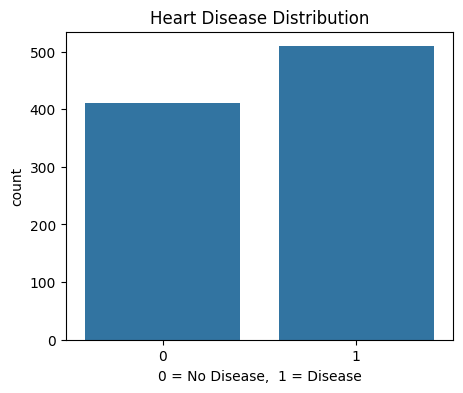


--- Numeric feature summary ---
              age         sex    trestbps        chol         fbs      thalch  \
count  920.000000  920.000000  920.000000  920.000000  920.000000  920.000000   
mean    53.510870    0.789130  131.995652  199.908696    0.150000  137.692391   
std      9.424685    0.408148   18.451300  109.040171    0.357266   25.145235   
min     28.000000    0.000000    0.000000    0.000000    0.000000   60.000000   
25%     47.000000    1.000000  120.000000  177.750000    0.000000  120.000000   
50%     54.000000    1.000000  130.000000  223.000000    0.000000  140.000000   
75%     60.000000    1.000000  140.000000  267.000000    0.000000  156.000000   
max     77.000000    1.000000  200.000000  603.000000    1.000000  202.000000   

            exang     oldpeak          ca      target  
count  920.000000  920.000000  920.000000  920.000000  
mean     0.366304    0.853261    0.227174    0.553261  
std      0.482056    1.058049    0.628936    0.497426  
min      0.00

In [10]:
# STEP: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Target balance ---
print("--- Target balance (0=No disease, 1=Disease) ---")
print(df_encoded['target'].value_counts())
print(df_encoded['target'].value_counts(normalize=True).round(3))

plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df_encoded)
plt.title('Heart Disease Distribution')
plt.xlabel('0 = No Disease,  1 = Disease')
plt.show()

# --- 2. Numeric summary ---
print("\n--- Numeric feature summary ---")
print(df_clean.describe())

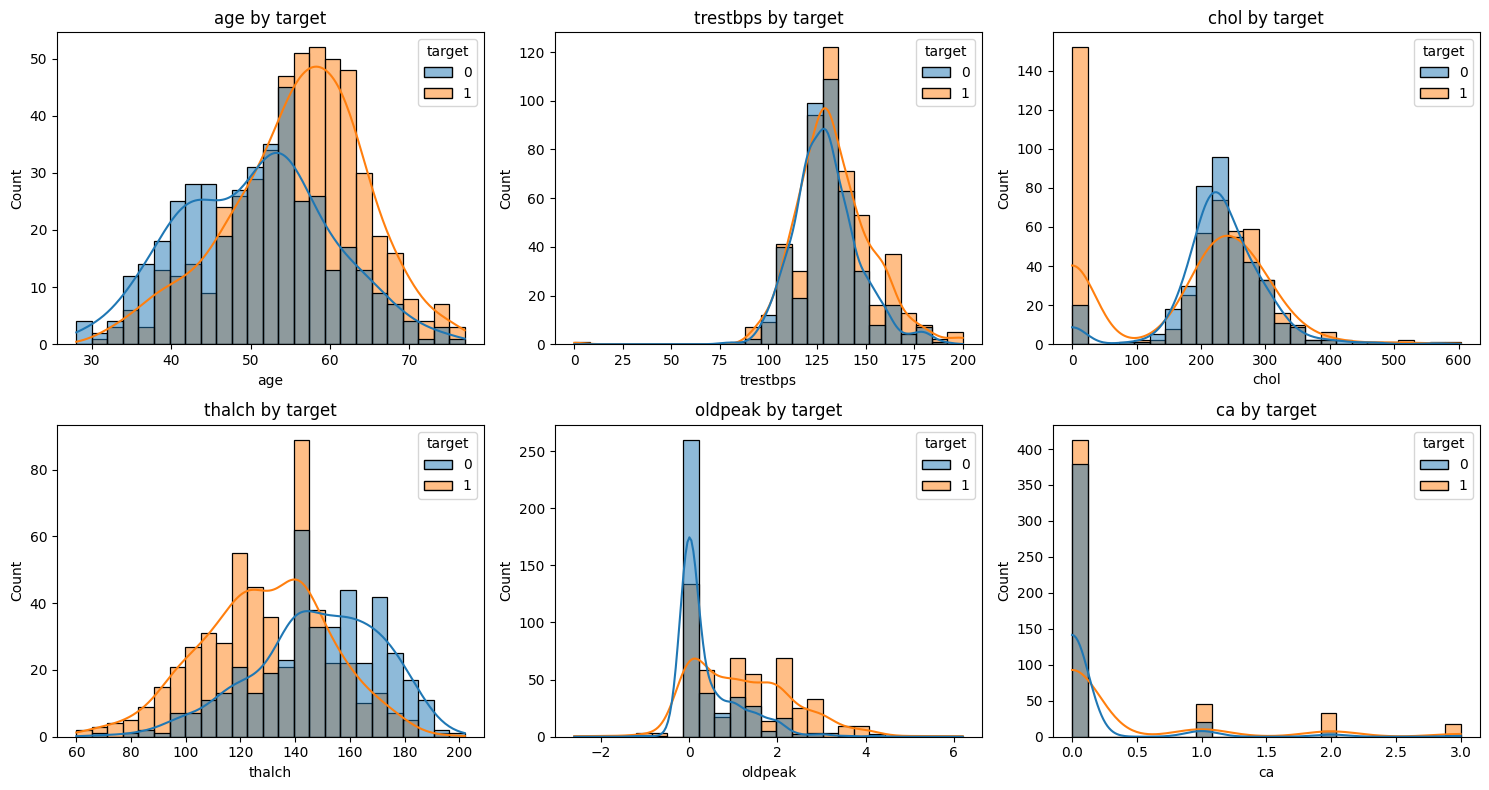

In [11]:
# --- 3. Distributions of key continuous features by target ---
num_feats = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), num_feats):
    sns.histplot(data=df_clean, x=feat, hue='target', kde=True, bins=25, ax=ax)
    ax.set_title(f'{feat} by target')
plt.tight_layout()
plt.show()

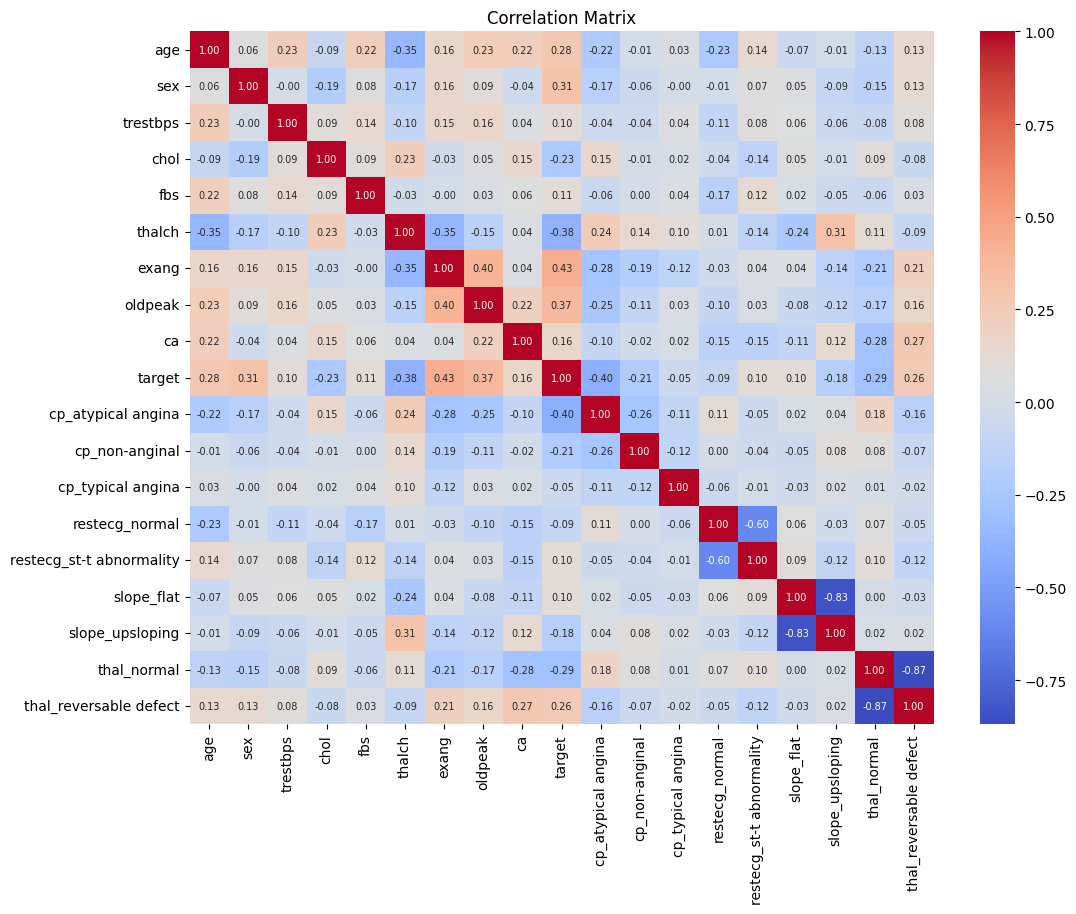


--- Correlation with target (sorted) ---
target                      1.000
exang                       0.434
oldpeak                     0.366
sex                         0.307
age                         0.283
thal_reversable defect      0.257
ca                          0.165
fbs                         0.108
restecg_st-t abnormality    0.105
trestbps                    0.101
slope_flat                  0.097
cp_typical angina          -0.055
restecg_normal             -0.094
slope_upsloping            -0.181
cp_non-anginal             -0.210
chol                       -0.229
thal_normal                -0.286
thalch                     -0.382
cp_atypical angina         -0.403
Name: target, dtype: float64


In [12]:
# --- 4. Correlation heatmap (full encoded feature set) ---
plt.figure(figsize=(12, 9))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'size': 7})
plt.title('Correlation Matrix')
plt.show()

# Which features correlate most with the target?
print("\n--- Correlation with target (sorted) ---")
print(df_encoded.corr()['target'].sort_values(ascending=False).round(3))

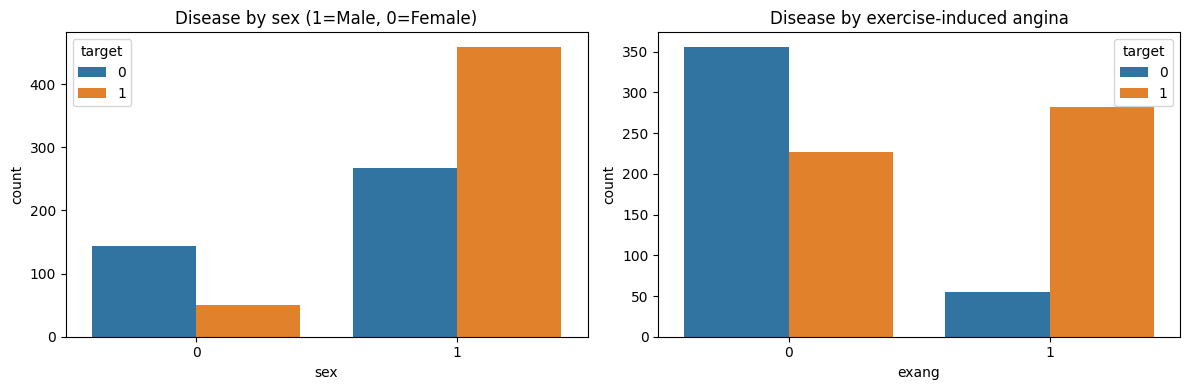

In [13]:
# --- 5. A couple of categorical relationships ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='sex', hue='target', data=df_clean, ax=axes[0])
axes[0].set_title('Disease by sex (1=Male, 0=Female)')
sns.countplot(x='exang', hue='target', data=df_clean, ax=axes[1])
axes[1].set_title('Disease by exercise-induced angina')
plt.tight_layout()
plt.show()

In [14]:
# STEP 4: Train/Test split + Feature scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 4a. Separate features (X) and target (y) ---
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# --- 4b. Split (stratify keeps the class ratio in both sets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test target balance:\n",  y_test.value_counts(normalize=True).round(3))

# --- 4c. Scale ONLY the continuous numeric features ---
num_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

scaler = StandardScaler()
# Fit on training data only, then transform both
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print("\n--- Scaled training features (first 3 rows) ---")
print(X_train[num_features].head(3))
print("\nMean of scaled train features (~0):")
print(X_train[num_features].mean().round(3))

Train shape: (736, 18)  Test shape: (184, 18)
Train target balance:
 target
1    0.553
0    0.447
Name: proportion, dtype: float64
Test target balance:
 target
1    0.554
0    0.446
Name: proportion, dtype: float64

--- Scaled training features (first 3 rows) ---
          age  trestbps      chol    thalch   oldpeak       ca
640 -0.063147  1.560270 -1.857816 -0.627205 -0.807883 -0.35792
743  2.180526 -0.116411 -1.857816  0.087627 -0.335827 -0.35792
890 -0.063147 -0.451747  0.382627 -0.627205  1.080341 -0.35792

Mean of scaled train features (~0):
age         0.0
trestbps    0.0
chol        0.0
thalch      0.0
oldpeak     0.0
ca         -0.0
dtype: float64


In [15]:
# STEP 5: Train Logistic Regression
from sklearn.linear_model import LogisticRegression

# max_iter raised to ensure convergence
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")
print("Training accuracy:", round(model.score(X_train, y_train), 4))
print("Test accuracy:    ", round(model.score(X_test, y_test), 4))

# --- Inspect the learned coefficients (feature influence) ---
import pandas as pd
coef = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\n--- Coefficients (positive = pushes toward disease) ---")
print(coef.to_string(index=False))

Model trained.
Training accuracy: 0.8166
Test accuracy:     0.8424

--- Coefficients (positive = pushes toward disease) ---
                 feature  coefficient
                     sex     1.121492
                   exang     1.010512
              slope_flat     0.719926
                      ca     0.531510
                 oldpeak     0.500260
                     fbs     0.362391
  thal_reversable defect     0.346439
restecg_st-t abnormality     0.283409
                     age     0.281546
                trestbps     0.062163
          restecg_normal    -0.062365
         slope_upsloping    -0.083208
                  thalch    -0.276574
             thal_normal    -0.322919
                    chol    -0.444951
       cp_typical angina    -0.923222
          cp_non-anginal    -1.062244
      cp_atypical angina    -1.776222


In [16]:
# STEP 6: Model Evaluation

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
import matplotlib.pyplot as plt

# --- Predictions on the test set ---
y_pred = model.predict(X_test)

# --- 6a. Core metrics ---
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=== Test Set Performance ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# --- 6b. Full classification report (per-class breakdown) ---
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

=== Test Set Performance ===
Accuracy : 0.8424
Precision: 0.8411
Recall   : 0.8824
F1 Score : 0.8612

--- Classification Report ---
              precision    recall  f1-score   support

  No Disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



Confusion matrix (raw):
 [[65 17]
 [12 90]]


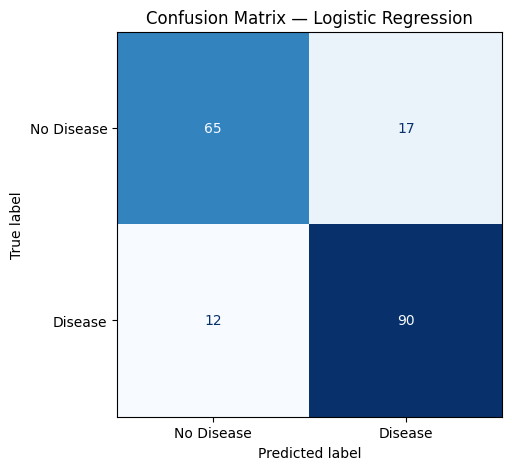

In [17]:
# --- 6c. Confusion matrix plot ---
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (raw):\n", cm)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.grid(False)
plt.show()